## 0. Configuración del Notebook
Importaremos todas las librerías y funciones que vemos relevantes para el notebook que vamos a crear. Lo ideal sería tener todas las importaciones juntas, de tal manera que se puedan controlar de manera sencilla.

### Librerias

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import pandas as pd
import seaborn as sns

### Definición de constantes

In [53]:
PATH_DIRECTORIO_DATOS = "../data/raw"
PATH_DATASET_CHURN = f"{PATH_DIRECTORIO_DATOS}/Telco-Churn.csv"

## 1. Inspección básica del dataset

### Diccionario de variables

El dataset contiene **21 columnas** y **7043 filas**. Cada fila representa un cliente.

#### Identificador
| Columna | Tipo | Descripcion |
|---|---|---|
| `customerID` | string | Identificador unico del cliente. No aporta informacion predictiva. |

#### Variables demograficas
| Columna | Tipo | Descripcion |
|---|---|---|
| `gender` | categorica | Sexo del cliente: `Male` / `Female`. |
| `SeniorCitizen` | binaria (0/1) | Indica si el cliente es mayor de 65 años. Codificado como entero, no como Yes/No. |
| `Partner` | binaria | El cliente tiene pareja: `Yes` / `No`. |
| `Dependents` | binaria | El cliente tiene personas a cargo (hijos, etc.): `Yes` / `No`. |

#### Variables de contrato y antiguedad
| Columna | Tipo | Descripcion |
|---|---|---|
| `tenure` | numerica (int) | Meses que lleva el cliente con la empresa. Rango: 0–72. |
| `Contract` | categorica | Tipo de contrato: `Month-to-month`, `One year`, `Two year`. Variable muy relevante para el churn. |
| `PaperlessBilling` | binaria | El cliente usa facturacion electronica: `Yes` / `No`. |
| `PaymentMethod` | categorica | Metodo de pago: `Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`. |

#### Servicios de telefonia
| Columna | Tipo | Descripcion |
|---|---|---|
| `PhoneService` | binaria | El cliente tiene servicio telefonico: `Yes` / `No`. |
| `MultipleLines` | categorica | El cliente tiene multiples lineas: `Yes`, `No`, `No phone service`. |

#### Servicios de internet
| Columna | Tipo | Descripcion |
|---|---|---|
| `InternetService` | categorica | Tipo de conexion a internet: `DSL`, `Fiber optic`, `No`. |
| `OnlineSecurity` | categorica | Tiene seguridad online contratada: `Yes`, `No`, `No internet service`. |
| `OnlineBackup` | categorica | Tiene copia de seguridad online: `Yes`, `No`, `No internet service`. |
| `DeviceProtection` | categorica | Tiene proteccion de dispositivos: `Yes`, `No`, `No internet service`. |
| `TechSupport` | categorica | Tiene soporte tecnico contratado: `Yes`, `No`, `No internet service`. |
| `StreamingTV` | categorica | Tiene streaming de TV: `Yes`, `No`, `No internet service`. |
| `StreamingMovies` | categorica | Tiene streaming de peliculas: `Yes`, `No`, `No internet service`. |

#### Variables economicas
| Columna | Tipo | Descripcion |
|---|---|---|
| `MonthlyCharges` | numerica (float) | Importe mensual que paga el cliente. |
| `TotalCharges` | numerica (float) | Importe total acumulado. **Ojo:** viene como `string` en el CSV, requiere conversion. Puede contener espacios en blanco. |

#### Variable objetivo (target)
| Columna | Tipo | Descripcion |
|---|---|---|
| `Churn` | binaria | El cliente se dio de baja: `Yes` / `No`. Es la variable que queremos predecir. |

### Inspección

In [54]:
df_churn = pd.read_csv(PATH_DATASET_CHURN)

In [55]:
# Primeras filas
df_churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
# Dimensiones del DataFrame
df_churn.shape

(7043, 21)

In [57]:
# Información del dataset
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [58]:
# Modificamos la columna TotalCharges a float ya que viene como string
df_churn['TotalCharges'] = df_churn['TotalCharges'].str.strip()
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')

In [59]:
# Volvemos a checkear
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [60]:
# Descripción estadística de las columnas numéricas. Recomendación el usar .transpose() para ver el listado de variables
df_churn.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [61]:
# Pasamos los nombres de las variables en minúsculas
df_churn.columns = df_churn.columns.str.lower()

In [62]:
df_churn.head(5)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
# Verificar si hay valores nulos en el DataFrame
df_churn.isna().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [66]:
# Vemos las filas en blanco para analizar
df_churn[df_churn['totalcharges'].isna()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [67]:
# Esas filas tienen valores nulos ya que no tienen ningún mes contratado todavía (columna tenure) por lo tanto imputamos con un 0
df_churn['totalcharges'] = df_churn['totalcharges'].fillna(0)

## 2. Analizar distribución de la variable targe Churn

### Distribución de la variable

In [81]:
target_column = "churn"
df_churn[target_column].value_counts(normalize = True).mul(100).round(2).astype(str) + " %"

churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: str

## 3. Correlaciones con heatmap y distribuciones de vaiables numéricas

### Correlaciones con heatmap

In [84]:
# Nos quedamos solo con las variables numéricas
numericas = df_churn[['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']]

# Calcular matriz de correlación
corr_matrix = numericas.corr()

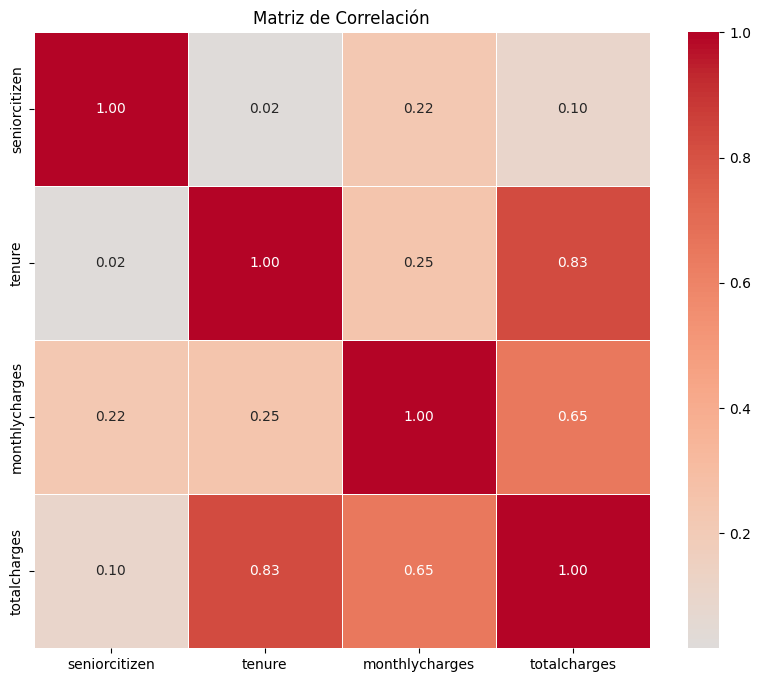

In [86]:
# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Muestra los valores numéricos en cada celda
    fmt=".2f",           # Formato de decimales
    cmap="coolwarm",     # Paleta de colores (azul=negativo, rojo=positivo)
    center=0,            # Centra la paleta en el valor 0
    square=True,         # Celdas cuadradas
    linewidths=0.5       # Grosor de las líneas entre celdas
)
plt.title("Matriz de Correlación")
plt.show()

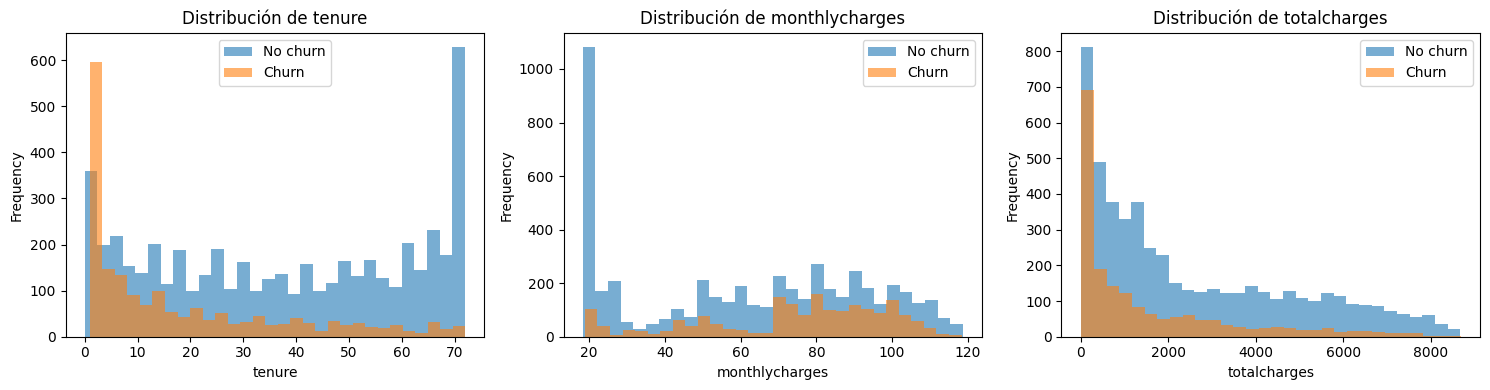

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'monthlycharges', 'totalcharges']):
  df_churn.groupby('churn')[col].plot(
      kind='hist', bins=30, alpha=0.6, ax=ax, legend=True
  )
  ax.set_title(f'Distribución de {col}')
  ax.set_xlabel(col)
  ax.legend(['No churn', 'Churn'])
  ax.legend(['No churn', 'Churn'])

plt.tight_layout()
plt.show()